# Interpretable Churn Modeling with a Generalized Additive Model (GAM)

**Goal:** Which model should a telecom company use if it wants an *interpretable* churn model, and what assumptions should it worry about before acting on the explanation?


**Roadmap:**
1. Load and clean the data
2. EDA aimed specifically at the assumptions a GAM needs (linearity of *log-odds* in each smooth term, collinearity between continuous predictors, coverage across the predictor range, class balance)
3. Fit the GAM
4. Evaluate predictive performance (and benchmark against plain logistic regression)
5. Interpret the fitted smooth effects
6. Discuss limitations of using a GAM for this decision


## 1. Clean and Load Dataset

In [25]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
from pygam import LogisticGAM, s, l

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

raw = pd.read_csv("data/Telco-Customer-Churn.csv")
print(raw.shape)
raw.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
raw.dtypes.to_frame("dtype")

,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


`TotalCharges` is read as `object` even though it's numeric. This is a sign of non-numeric (blank) entries. Also `customerID` is an identifier we don't want the model to use

In [27]:
# TotalCharges has blank strings for brand-new customers
blank_mask = raw["TotalCharges"].astype(str).str.strip() == ""
print(f"Blank TotalCharges rows: {blank_mask.sum()}")
print(raw.loc[blank_mask, ["tenure", "MonthlyCharges", "TotalCharges"]])

df = raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


Blank TotalCharges rows: 11
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25             
936        0           80.85             
1082       0           25.75             
1340       0           56.05             
3331       0           19.85             
3826       0           25.35             
4380       0           20.00             
5218       0           19.70             
6670       0           73.35             
6754       0           61.90             


These are genuine new customers (tenure=0), not a random missing-data problem, and there's no sensible TotalCharges to impute for them (they haven't been billed yet), so we should drop them rather than invent a value.

In [28]:
df = df.dropna(subset=["TotalCharges"]).reset_index(drop=True)
df = df.drop(columns=["customerID"])
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(f"\nRows after cleaning: {len(df)}  (dropped {len(raw) - len(df)})")
print(f"Remaining missing values: {df.isna().sum().sum()}")
df.head()


Rows after cleaning: 7032  (dropped 11)
Remaining missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. EDA Relevant to GAM Assumptions

A GAM for a binary outcome makes a specific set of assumptions:

1. **Correct response family** — the target should genuinely be binary/Bernoulli, and not so imbalanced that a binomial GAM has nothing to learn from the minority class.
2. **Independent observations** — each row must be one independent draw (no repeated measurements or panel structure the model isn't told about).
3. **Additivity** — the *combined* effect of predictors on the log-odds is a sum of individual terms, with no built-in interactions between them.
4. **Smoothness / linearity-in-log-odds is not assumed away** — this is the actual reason to prefer a GAM over plain logistic regression: we should check whether the relationship between a continuous predictor and the log-odds of churn actually looks curved (if it's already linear, the smooth term is wasted flexibility, not wrong).
5. **No severe multicollinearity between the continuous predictors** — the backfitting/penalized-spline fit used to estimate smooth terms becomes unstable and effects become hard to attribute when continuous predictors are highly correlated.
6. **Sufficient, well-distributed data across the range of each continuous predictor** — a spline is a local, flexible fit, so sparse regions of a predictor's range produce wide, unreliable, wiggly estimates.

We check 1, 4, 5, and 6 directly below; 2 and 3 are structural assumptions about the data-generating process that EDA alone can't confirm (discussed in the Limitations section).

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


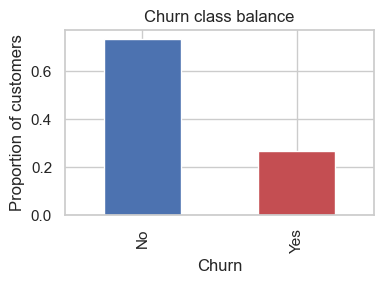

In [4]:
# (1) Response family / class balance
churn_rate = df["Churn"].value_counts(normalize=True).rename({0: "No", 1: "Yes"})
print(churn_rate)

fig, ax = plt.subplots(figsize=(4, 3))
churn_rate.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Proportion of customers")
ax.set_title("Churn class balance")
plt.tight_layout()
plt.show()

~26.5% churn and  ~73.5% no-churn
This is not extreme, but imbalanced enough that accuracy alone will be a misleading metric. So we'll also report ROC-AUC and per-class precision/recall.

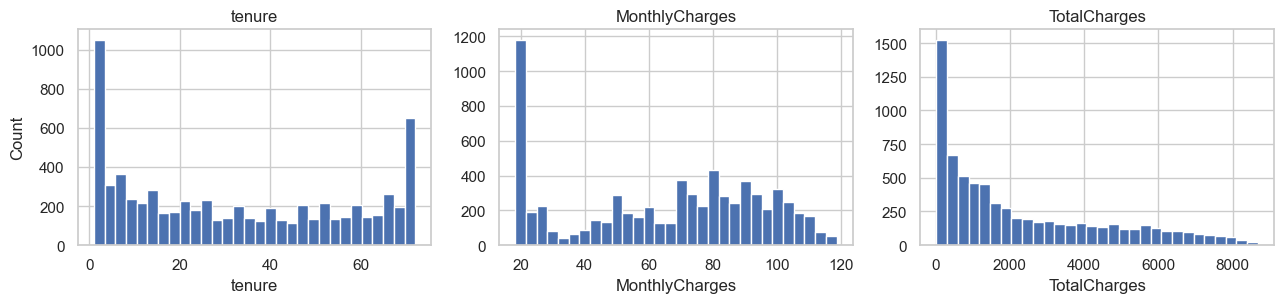

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [5]:
# (6) Coverage across the range of each continuous predictor — check for sparse/thin regions
cont_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
for ax, col in zip(axes, cont_cols):
    ax.hist(df[col], bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

df[cont_cols].describe()

`tenure` (1–72 months) and `MonthlyCharges` (\$18–\$119) both have full, reasonably dense coverage across their range. There are no thin regions that would make a spline unstable at the edges. 
`TotalCharges` is heavily right-skewed (it's roughly tenure × MonthlyCharges).

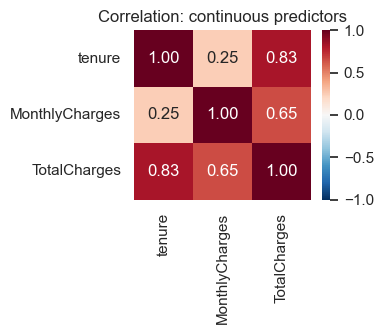

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


In [6]:
# (5) Multicollinearity between the continuous predictors
corr = df[cont_cols].corr()
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation: continuous predictors")
plt.tight_layout()
plt.show()
corr

`TotalCharges` correlates strongly with `tenure` (r ≈ 0.83) and moderately with `MonthlyCharges` (r ≈ 0.65). THis is expected, since it's essentially their product accumulated over time. 

Feeding all three into a GAM as separate smooth terms would let the splines fight over the same signal and produce unstable, hard-to-interpret shapes. 
THus, **drop `TotalCharges` and keep smooth terms only for `tenure` and `MonthlyCharges`**, which are far less collinear with each other (r ≈ 0.25).

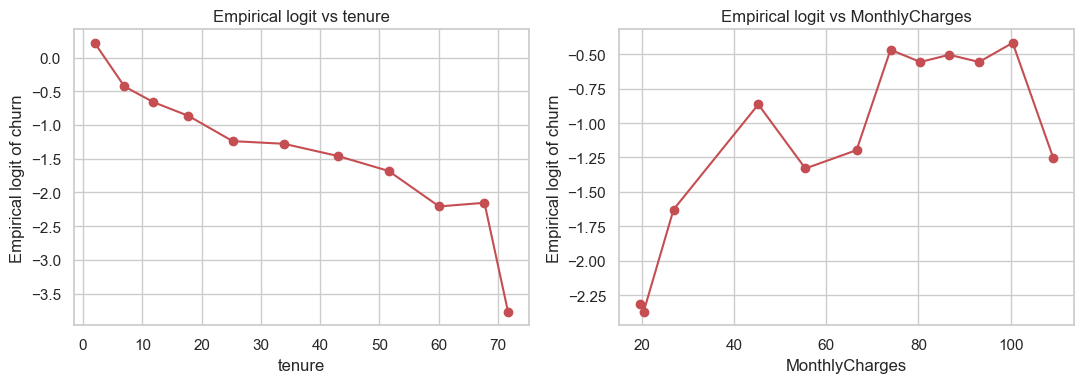

,mid,n,rate,logit
bin,,,,
"(0.999, 4.0]",1.950285,1227,0.554197,0.217644
"(4.0, 9.0]",6.975649,616,0.394481,-0.428517
"(9.0, 14.0]",11.864603,517,0.340426,-0.661398
"(14.0, 21.583]",17.754386,570,0.296491,-0.864063
"(21.583, 29.0]",25.235669,628,0.224522,-1.239504
"(29.0, 38.0]",33.889447,597,0.217755,-1.278795
"(38.0, 47.0]",43.080139,574,0.188153,-1.462054
"(47.0, 55.0]",51.525547,548,0.156934,-1.681218
"(55.0, 64.0]",60.066563,646,0.099071,-2.207587


In [29]:
# (4) Is the log-odds of churn actually linear in each continuous predictor?
def empirical_logit_plot(data, col, bins, ax):
    tmp = data[[col, "Churn"]].copy()
    tmp["bin"] = pd.qcut(tmp[col], q=bins, duplicates="drop")
    g = tmp.groupby("bin", observed=True).agg(rate=("Churn", "mean"), n=("Churn", "size"),
                                               mid=(col, "mean"))
    eps = 0.5 / g["n"]  # small continuity correction so rate=0/1 bins don't blow up the logit
    rate_adj = g["rate"].clip(eps, 1 - eps)
    logit = np.log(rate_adj / (1 - rate_adj))
    ax.plot(g["mid"], logit, "o-", color="#C44E52")
    ax.set_xlabel(col)
    ax.set_ylabel("Empirical logit of churn")
    ax.set_title(f"Empirical logit vs {col}")
    return g.assign(logit=logit)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tenure_bins = empirical_logit_plot(df, "tenure", 12, axes[0])
mc_bins = empirical_logit_plot(df, "MonthlyCharges", 12, axes[1])
plt.tight_layout()
plt.show()

tenure_bins[["mid", "n", "rate", "logit"]]

The empirical-logit plot for `tenure` is a clear, mostly monotonic *curve* (steep drop in early tenure, flattening out later). It's not a straight line, so a smooth term for `tenure` is justified over a single linear coefficient. 

The `MonthlyCharges` empirical-logit plot is non-monotonic (dips and bumps rather than a straight trend), also supporting a smooth rather than linear term, though with more noise given the confounding services bundled at each price point.

### EDA takeaways
Based on this, the GAM specification is: smooth terms `s(tenure)` and `s(MonthlyCharges)`, and linear terms for the remaining (mostly categorical/binary) predictors.

## 3. GAM Model

Categorical predictors are one-hot encoded (dropping one level each to avoid redundant, perfectly collinear dummy columns) and entered as linear terms `l()`; `tenure` and `MonthlyCharges` are entered as penalized-spline smooth terms `s()`. We use `pygam`'s `LogisticGAM` (binomial family, logit link) and select the smoothing penalty `lambda` by grid search.

In [30]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

X = pd.get_dummies(
    df.drop(columns=["Churn", "TotalCharges"]),  # dropped for collinearity, see EDA
    columns=cat_cols,
    drop_first=True,
)
y = df["Churn"].values

tenure_idx = X.columns.get_loc("tenure")
mc_idx = X.columns.get_loc("MonthlyCharges")
linear_idx = [i for i in range(X.shape[1]) if i not in (tenure_idx, mc_idx)]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print(f"Features: {X.shape[1]}  |  train: {X_train.shape[0]}  |  test: {X_test.shape[0]}")
print(f"Smooth terms: tenure (col {tenure_idx}), MonthlyCharges (col {mc_idx})")

Features: 29  |  train: 5274  |  test: 1758
Smooth terms: tenure (col 1), MonthlyCharges (col 2)


In [31]:
terms = s(tenure_idx, n_splines=15) + s(mc_idx, n_splines=15)
for i in linear_idx:
    terms += l(i)

gam = LogisticGAM(terms)
gam.gridsearch(
    X_train.values.astype(float), y_train,
    lam=np.logspace(-3, 3, 8), progress=False,
)

gam.summary()

LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                       33.62
Link Function:                        LogitLink Log Likelihood:                                 -2126.9654
Number of Samples:                         5274 AIC:                                             4321.1707
                                                AICc:                                            4321.6415
                                                UBRE:                                               2.8244
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.3036
Feature Function                  Lam

## 4. Model Performance Evidence

I'll evaluate on the held-out test set (accuracy, ROC-AUC, confusion matrix, precision/recall) and benchmark against a plain logistic regression (all predictors entered linearly, including `tenure`/`MonthlyCharges`) fit on the same train/test split, to see what the smooth terms buy us.

GAM  accuracy: 0.801
GAM  ROC-AUC : 0.844
GAM  effective DoF: 33.6  (vs. 30 raw params)

              precision    recall  f1-score   support

    No churn      0.842     0.898     0.869      1291
       Churn      0.654     0.535     0.589       467

    accuracy                          0.801      1758
   macro avg      0.748     0.717     0.729      1758
weighted avg      0.792     0.801     0.795      1758



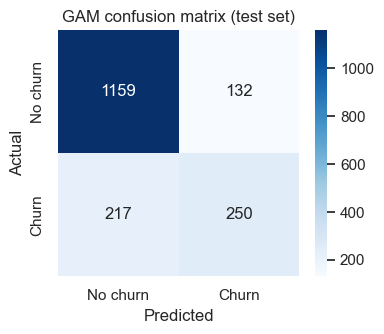

In [32]:
gam_pred = gam.predict(X_test.values.astype(float))
gam_proba = gam.predict_proba(X_test.values.astype(float))

print(f"GAM  accuracy: {accuracy_score(y_test, gam_pred):.3f}")
print(f"GAM  ROC-AUC : {roc_auc_score(y_test, gam_proba):.3f}")
print(f"GAM  effective DoF: {gam.statistics_['edof']:.1f}  (vs. {X.shape[1]+1} raw params)")
print()
print(classification_report(y_test, gam_pred, digits=3, target_names=["No churn", "Churn"]))

cm = confusion_matrix(y_test, gam_pred)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("GAM confusion matrix (test set)")
plt.tight_layout()
plt.show()

Logistic Regression accuracy: 0.807
Logistic Regression ROC-AUC : 0.838


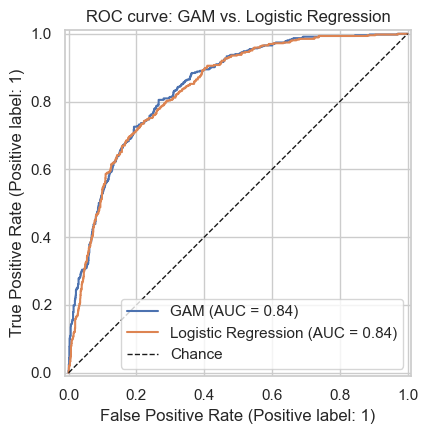

In [33]:
# Benchmark: plain logistic regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
lr_proba = lr.predict_proba(X_test)[:, 1]
lr_pred = lr.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, lr_pred):.3f}")
print(f"Logistic Regression ROC-AUC : {roc_auc_score(y_test, lr_proba):.3f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_predictions(y_test, gam_proba, name="GAM", ax=ax)
RocCurveDisplay.from_predictions(y_test, lr_proba, name="Logistic Regression", ax=ax)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
ax.set_title("ROC curve: GAM vs. Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Smooth Effect Interpretation

Each smooth term contributes its own additive piece to the predicted log-odds of churn, independent of every other term's value. We plot the partial dependence (the fitted `f(x)` curve) with a 95% confidence band for `tenure` and `MonthlyCharges`.

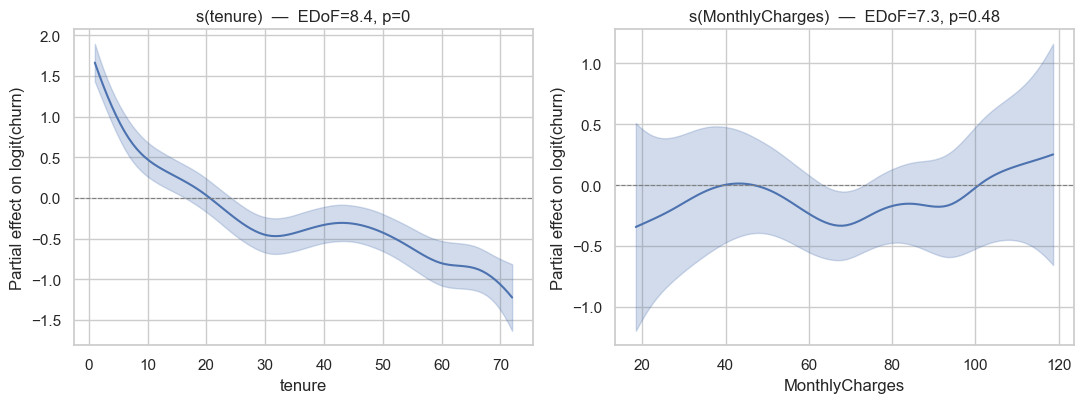

In [34]:
smooth_terms = [(0, tenure_idx, "tenure"), (1, mc_idx, "MonthlyCharges")]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (term_i, col_idx, name) in zip(axes, smooth_terms):
    XX = gam.generate_X_grid(term=term_i)
    pdep, confi = gam.partial_dependence(term=term_i, X=XX, width=0.95)
    edof = gam.statistics_["edof_per_coef"][gam.terms.get_coef_indices(term_i)].sum()
    pval = gam.statistics_["p_values"][term_i]

    ax.plot(XX[:, col_idx], pdep, color="#4C72B0")
    ax.fill_between(XX[:, col_idx], confi[:, 0], confi[:, 1], alpha=0.25, color="#4C72B0")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel(name)
    ax.set_ylabel("Partial effect on logit(churn)")
    ax.set_title(f"s({name})  —  EDoF={edof:.1f}, p={pval:.3g}")
plt.tight_layout()
plt.show()


**`s(tenure)`** 

EDoF ≈ 8.4, p < 0.001 — a real, non-linear effect 

The partial log-odds of churn starts high (≈ +1.7 at 1 month) and falls steeply over the first ~18 months, then keeps declining but much more gently out to 72 months (≈ −1.2 at the longest tenures). THis means **the first year and a half is where almost all of the "flight risk" lives**,a customer who survives that window is already far less likely to churn, and each additional year beyond that buys progressively smaller reductions in risk. A linear term (plain logistic regression) would spread this same total swing evenly across the whole tenure range and understate the urgency of the early months.

**`s(MonthlyCharges)`** 

EDoF ≈ 7.3, p ≈ 0.48 — *not* statistically significant
 
The curve does go up and down (dips around \$30–60, rises again above \$100), but its 95% confidence band overlaps zero almost everywhere. This means **that up-and-down shape probably isn't real, it could just be noise**, so it's not something the company should design a strategy around. Once `tenure` and the specific services a customer has are already in the model, `MonthlyCharges` doesn't add much reliable extra information on its own. The pattern we noticed earlier in the raw data was probably really coming from *which services* drive both the price and the churn risk (fiber, streaming add-ons, and so on) not from the price itself.

**Conclusion**

the GAM reaches ROC-AUC ≈ 0.844 vs. ≈ 0.838 for plain logistic regression. The practical value of the GAM here is less about the accuracy gain and more about **correctly locating where risk concentrates in tenure**, which a linear coefficient would have hidden.

## 6. Limitations of Using a GAM for Churn

Before the telecom company acts on these smooth-effect explanations, it should weigh:

- **Additivity hides interactions.** The model assumes `s(tenure)` affects churn the same way for everyone, but a month-to-month customer probably behaves differently over time than someone on a 2-year contract. Capturing that would need interaction terms, which start to undo the "just read the curve" simplicity that makes a GAM appealing.

- **Association, not causation.** Churn dropping as `s(tenure)` increases doesn't mean keeping someone longer would lower their risk. Customers still around at month 40 already survived the risky early period, the curve describes who stuck around, not what happens if you try to extend someone's tenure artificially.

- **Identifiability with mixed smooth + linear terms.** `pygam` itself warns that combining spline and linear terms on correlated inputs makes the reported p-values unreliable (they reject the null too readily once the smoothing parameter is estimated from the data rather than fixed in advance). We should treat "tenure is significant" as a useful hint, not a rigorous statistical proof.

- **Sensitivity to the collinearity workaround.** We dropped `TotalCharges` to avoid an unstable fit. We removed it to avoid instability from collinearity, which was the right call — but it means we can't say anything separately about a customer's total spend; whatever signal it carried is now smeared across `tenure` and `MonthlyCharges`.

- **Non-i.i.d. structure isn't modeled.** The model treats every row as unrelated, but churn can cluster — shared households, regional outages, promo cohorts. Ignoring that can make the confidence bands look tighter than they should.

- **Moderate class imbalance and modest recall.** At the default 0.5 threshold, the GAM only catches about half of actual churners (recall ≈ 0.53 on the "Churn" class); a retention program acting on this model as-is would miss a large share of at-risk customers unless the decision threshold is deliberately lowered for this use case.

## Recommendation

For a telecom company that wants to actually explain why customers churn (not just get a prediction), I'd recommend the GAM over a black-box model. It's basically as easy to read as a normal logistic regression, but it doesn't force the tenure effect to be a straight line and that mattered here, since we found churn risk drops off really fast in the first ~18 months and then levels out. That's a useful, actionable finding (focus retention efforts early) that a regular logistic regression would have missed since it can only fit a straight line. That said, the model still comes with the limitations mentioned above, so the smooth curves should be used to point the company in the right direction, not treated as an exact cause-and-effect explanation for retention decisions.
